# HW5 — Fine-Tuning an LLM with LoRA (PEFT) on DialogSum

**Model:** `google/flan-t5-small` (≈77M params, encoder–decoder) &nbsp;|&nbsp; **Dataset:** [`neil-code/dialogsum-test`](https://huggingface.co/datasets/neil-code/dialogsum-test) &nbsp;|&nbsp; **SEED = 1605**

Pipeline: data prep → zero-shot baseline → attach LoRA adapters → fine-tune → re-run the same 2 dialogues → compare → rank experiment (r=4 vs r=16).

In [1]:
import os, json, time, random
import numpy as np
import pandas as pd
import torch
import transformers, peft, datasets
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq,
                          Seq2SeqTrainer, Seq2SeqTrainingArguments, set_seed)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

SEED = 1605
set_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
MODEL_NAME = "google/flan-t5-small"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
pd.set_option("display.max_colwidth", None)

print(f"torch {torch.__version__} | transformers {transformers.__version__} | peft {peft.__version__} | datasets {datasets.__version__}")
print("device:", DEVICE)

torch 2.11.0 | transformers 5.5.3 | peft 0.21.1 | datasets 4.0.0
device: mps


## 1. Data Preparation

Load DialogSum and convert every example into an **input** (the dialogue, wrapped in an instruction prompt, since FLAN-T5 is instruction-tuned) and a **target** (the human-written summary).

In [2]:
raw = load_dataset("neil-code/dialogsum-test")
print(raw)

PROMPT = "Summarize the following conversation.\n\n{dialogue}\n\nSummary:"

def to_io(ex):
    return {"input": PROMPT.format(dialogue=ex["dialogue"]), "target": ex["summary"]}

data = raw.map(to_io, remove_columns=raw["train"].column_names)
print(data)

Using the latest cached version of the dataset since neil-code/dialogsum-test couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'default' at /Users/rajesh_paruchuri/.cache/huggingface/datasets/neil-code___dialogsum-test/default/0.0.0/f0524dd2e0267dc8102109ce1b14bae8f97976d3 (last modified on Tue Sep 29 12:26:32 2026).


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
})
DatasetDict({
    train: Dataset({
        features: ['input', 'target'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['input', 'target'],
        num_rows: 499
    })
    test: Dataset({
        features: ['input', 'target'],
        num_rows: 499
    })
})


In [3]:
for i in range(2):
    ex = data["train"][i]
    print(f"================ Processed sample {i} ================")
    print("INPUT:\n" + ex["input"])
    print("\nTARGET:\n" + ex["target"] + "\n")

================ Processed sample 0 ================
INPUT:
Summarize the following conversation.

#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. Why are you here today?
#Person2#: I found it would be a good idea to get a check-up.
#Person1#: Yes, well, you haven't had one for 5 years. You should have one every year.
#Person2#: I know. I figure as long as there is nothing wrong, why go see the doctor?
#Person1#: Well, the best way to avoid serious illnesses is to find out about them early. So try to come at least once a year for your own good.
#Person2#: Ok.
#Person1#: Let me see here. Your eyes and ears look fine. Take a deep breath, please. Do you smoke, Mr. Smith?
#Person2#: Yes.
#Person1#: Smoking is the leading cause of lung cancer and heart disease, you know. You really should quit.
#Person2#: I've tried hundreds of times, but I just can't seem to kick the habit.
#Person1#: Well, we have classes and some medications that might help. I'll give you more information before you leave.

Tokenize: inputs truncated to 512 tokens (FLAN-T5's context; ~99% of dialogues fit), targets to 128 tokens. Pad tokens in the labels are replaced by `-100` by the collator so they are ignored by the loss.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_IN, MAX_OUT = 512, 128

def tokenize(batch):
    enc = tokenizer(batch["input"], max_length=MAX_IN, truncation=True)
    enc["labels"] = tokenizer(text_target=batch["target"], max_length=MAX_OUT, truncation=True)["input_ids"]
    return enc

tokenized = data.map(tokenize, batched=True, remove_columns=["input", "target"])
print(tokenized)
print("example input_ids length:", len(tokenized["train"][0]["input_ids"]), "| labels length:", len(tokenized["train"][0]["labels"]))

Map:   0%|          | 0/499 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 499
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 499
    })
})
example input_ids length: 293 | labels length: 48


## 2. Baseline Inference (zero-shot, before fine-tuning)

Two fixed, **distinct** dialogues from the **test** split (none of the 167 test dialogues appear in train). Note: this test split lists each of its 167 dialogues **three times**, once per human reference summary (`test_0_1`, `test_0_2`, `test_0_3`, …), so rows 0 and 1 are the *same* dialogue — the samples below are grouped by unique dialogue instead.

Decoding is identical for every model: deterministic beam search (`num_beams=4`, `do_sample=False`) with `no_repeat_ngram_size=6`. This setting was chosen on **validation** dialogues 200–299 (not the test set), comparing six options for the r=16 adapter:

| Decoding | ROUGE-1 | ROUGE-2 | ROUGE-L | mangled speaker tags | looping summaries |
|---|---|---|---|---|---|
| greedy | 40.70 | 16.03 | 34.24 | 0/100 | 2/100 |
| greedy + no_repeat_ngram 3 | 36.91 | 14.62 | 31.54 | **67/100** | 1/100 |
| greedy + no_repeat_ngram 6 | 40.99 | 16.22 | 34.37 | 12/100 | 1/100 |
| greedy + repetition_penalty 1.2 | 41.75 | 16.55 | 34.74 | 0/100 | 2/100 |
| beam 4 | 41.10 | 16.21 | 33.69 | 0/100 | 4/100 |
| **beam 4 + no_repeat_ngram 6** | **42.40** | **17.01** | 34.52 | **0/100** | **0/100** |

Why: plain greedy decoding sometimes loops a whole clause (*"Ms. Dawson asks #Person1# to take a dictation for Ms. Dawson. Ms. Dawson asks …"*), but the common fix `no_repeat_ngram_size=3` breaks DialogSum's speaker tags — `#Person2#` is 5 subword tokens (`▁# P erson 2 #`), so trigram blocking forbids writing a tag twice and yields `#Pperson2#`, `#Pon2#`. Blocking only 6-grams stops clause loops while leaving tags intact.

In [5]:
# group the test split by unique dialogue -> list of its 3 reference summaries (order preserved)
test_groups = {}
for d, s in zip(raw["test"]["dialogue"], raw["test"]["summary"]):
    test_groups.setdefault(d, []).append(s)
test_dialogues = list(test_groups)
print(f"test rows: {len(raw['test'])} | unique test dialogues: {len(test_dialogues)} | refs per dialogue: {sorted(set(map(len, test_groups.values())))}")

EVAL_IDX = [0, 1]  # indices into the unique test dialogues (test_0_*, test_1_*), reused for every comparison
eval_dialogues = [test_dialogues[i] for i in EVAL_IDX]
eval_refs = [test_groups[d][0] for d in eval_dialogues]  # first human reference shown for readability

@torch.no_grad()
def summarize(model, dialogues, batch_size=8, max_new_tokens=128):
    model.eval()
    outs = []
    for s in range(0, len(dialogues), batch_size):
        prompts = [PROMPT.format(dialogue=d) for d in dialogues[s:s + batch_size]]
        enc = tokenizer(prompts, max_length=MAX_IN, truncation=True, padding=True, return_tensors="pt").to(model.device)
        gen = model.generate(**enc, max_new_tokens=max_new_tokens, num_beams=4, do_sample=False,
                             no_repeat_ngram_size=6)
        outs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
    return outs

base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
baseline_outputs = summarize(base_model, eval_dialogues)

for i, (d, ref, out) in enumerate(zip(eval_dialogues, eval_refs, baseline_outputs)):
    print(f"================ Test dialogue {EVAL_IDX[i]} ================")
    print(d)
    print("\nREFERENCE SUMMARY :", ref)
    print("BASELINE (zero-shot):", out, "\n")

with open(f"{OUT_DIR}/baseline_outputs.json", "w") as f:
    json.dump([{"test_idx": i, "dialogue": d, "reference": r, "baseline": o}
               for i, d, r, o in zip(EVAL_IDX, eval_dialogues, eval_refs, baseline_outputs)], f, indent=2)
print(f"Saved baseline outputs -> {OUT_DIR}/baseline_outputs.json")

test rows: 499 | unique test dialogues: 167 | refs per dialogue: [1, 3]


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


================ Test dialogue 0 ================
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too

To measure quality beyond two examples, compute ROUGE (F1, with stemming) on **all 167 unique test dialogues**, scoring each prediction against each of its human references (3 for 166 dialogues, 1 for the remaining one) and averaging — the standard DialogSum multi-reference protocol. The same set is reused for every model.

In [6]:
from rouge_score import rouge_scorer
ROUGE_KEYS = ["rouge1", "rouge2", "rougeL"]
scorer = rouge_scorer.RougeScorer(ROUGE_KEYS, use_stemmer=True)
N_ROUGE = len(test_dialogues)

def rouge_eval(model):
    preds = summarize(model, test_dialogues)
    per_ex = [scorer.score(ref, pred) for pred, d in zip(preds, test_dialogues) for ref in test_groups[d]]
    scores = {k: round(100 * float(np.mean([s[k].fmeasure for s in per_ex])), 2) for k in ROUGE_KEYS}
    scores["avg_words"] = round(float(np.mean([len(p.split()) for p in preds])), 1)
    return scores

t0 = time.time()
rouge_results = {"Baseline (zero-shot)": rouge_eval(base_model)}
print(f"Baseline ROUGE on {N_ROUGE} test dialogues ({time.time() - t0:.0f}s):", rouge_results["Baseline (zero-shot)"])
print("Reference avg words:", round(float(np.mean([len(r.split()) for r in raw["test"]["summary"]])), 1))
del base_model

Baseline ROUGE on 167 test dialogues (119s): {'rouge1': 17.45, 'rouge2': 5.33, 'rougeL': 14.89, 'avg_words': 10.7}
Reference avg words: 19.3


## 3. Apply LoRA

LoRA freezes all pretrained weights $W$ and learns a low-rank update $\Delta W = \frac{\alpha}{r} BA$ with $B \in \mathbb{R}^{d\times r}$, $A \in \mathbb{R}^{r\times k}$. Adapters go on the **query and value projections (`q`, `v`)** of every self- and cross-attention block (the original LoRA paper's setting).

Main configuration: **r = 16, lora_alpha = 32 (scale α/r = 2), lora_dropout = 0.05**. Section 7 repeats everything with r = 4 (and α = 8, so the α/r scale stays at 2 and only the rank changes).

In [7]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def build_lora_model(r, alpha, dropout=0.05):
    set_seed(SEED)  # identical adapter init / data order for every rank
    base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    cfg = LoraConfig(task_type=TaskType.SEQ_2_SEQ_LM, r=r, lora_alpha=alpha, lora_dropout=dropout,
                     target_modules=["q", "v"], bias="none")
    return get_peft_model(base, cfg), cfg

_tmp = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
frozen_total, _ = count_params(_tmp)
del _tmp
lora16, cfg16 = build_lora_model(r=16, alpha=32)
print(cfg16)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


LoraConfig(task_type=<TaskType.SEQ_2_SEQ_LM: 'SEQ_2_SEQ_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.21.1', base_model_name_or_path='google/flan-t5-small', revision=None, inference_mode=False, r=16, target_modules={'v', 'q'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, kasa_config=None, ensure_weight_tying=False)


In [8]:
total, trainable = count_params(lora16)
print(f"Base model parameters (no LoRA): {frozen_total:,}")
print(f"Total parameters (with LoRA)   : {total:,}")
print(f"Trainable parameters (LoRA only): {trainable:,}  ({100 * trainable / total:.3f}% of total)")
lora16.print_trainable_parameters()
print("\nExample adapted layer:\n", lora16.base_model.model.encoder.block[0].layer[0].SelfAttention.q)

Base model parameters (no LoRA): 76,961,152
Total parameters (with LoRA)   : 77,649,280
Trainable parameters (LoRA only): 688,128  (0.886% of total)
trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862

Example adapted layer:
 lora.Linear(
  (base_layer): Linear(in_features=512, out_features=384, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=512, out_features=16, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=16, out_features=384, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)


## 4. Fine-Tuning

**Subset (allowed by the assignment):** a random 1,000 of the 1,999 training dialogues (shuffled with SEED), 2 epochs, AdamW lr = 1e-3 (LoRA tolerates much higher learning rates than full fine-tuning), linear decay with warmup. Batch size 8, no gradient accumulation (with accumulation, this transformers version logged a training loss ≈2× the true value — see AI_USE.md). Two earlier attempts with `flan-t5-base` exhausted the 16 GB machine's RAM and stalled in swap (see RUN_LOG.txt), so this notebook uses `flan-t5-small`, the model the assignment suggests. Validation loss is logged every epoch on 200 held-out validation dialogues.

In [9]:
from transformers import TrainerCallback

N_TRAIN = 1000
train_subset = tokenized["train"].shuffle(seed=SEED).select(range(N_TRAIN))
val_subset = tokenized["validation"].select(range(200))

class ProgressFile(TrainerCallback):
    # writes one line per logging step to a file, so progress is visible while the notebook executes headless
    def __init__(self, path): self.path = path; open(path, "w").close()
    def on_log(self, args, state, control, logs=None, **kw):
        with open(self.path, "a") as f:
            f.write(f"{time.strftime('%H:%M:%S')} step {state.global_step}/{state.max_steps} {json.dumps(logs)}\n")

def train_lora(model, run_name, epochs=2, lr=1e-3, bs=8, grad_accum=1):
    args = Seq2SeqTrainingArguments(
        output_dir=f"{OUT_DIR}/checkpoints_{run_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        gradient_accumulation_steps=grad_accum,
        learning_rate=lr,
        warmup_ratio=0.05,
        lr_scheduler_type="linear",
        weight_decay=0.0,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=SEED,
        dataloader_pin_memory=False,
    )
    trainer = Seq2SeqTrainer(
        model=model, args=args,
        train_dataset=train_subset, eval_dataset=val_subset,
        data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
        processing_class=tokenizer,
        callbacks=[ProgressFile(f"{OUT_DIR}/train_progress_{run_name}.log")],
    )
    t0 = time.time()
    result = trainer.train()
    minutes = (time.time() - t0) / 60
    logs = pd.DataFrame(trainer.state.log_history)
    return trainer, result, logs, minutes

trainer16, result16, logs16, mins16 = train_lora(lora16, "r16")
print(f"Training time: {mins16:.1f} min")
print(f"Final (average) training loss: {result16.training_loss:.4f}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,1.559087,1.337176
2,1.409934,1.316714


Training time: 18.3 min
Final (average) training loss: 1.6016


In [10]:
train_log16 = logs16.dropna(subset=["loss"])[["step", "epoch", "loss", "learning_rate"]].reset_index(drop=True)
eval_log16 = logs16.dropna(subset=["eval_loss"])[["epoch", "eval_loss"]].reset_index(drop=True)
print("Training loss log (every 10 optimizer steps):")
display(train_log16)
print("Validation loss per epoch:")
display(eval_log16)
print(f"First logged train loss: {train_log16.loss.iloc[0]:.4f}  ->  final logged train loss: {train_log16.loss.iloc[-1]:.4f}")

Training loss log (every 10 optimizer steps):


,step,epoch,loss,learning_rate
0,10,0.08,2.405278,0.000692
1,20,0.16,1.889982,0.000975
2,30,0.24,1.687075,0.000932
3,40,0.32,1.718535,0.000890
4,50,0.40,1.759120,0.000848
5,60,0.48,1.543504,0.000806
6,70,0.56,1.627386,0.000764
7,80,0.64,1.590759,0.000722
8,90,0.72,1.621355,0.000679
9,100,0.80,1.544022,0.000637


Validation loss per epoch:


,epoch,eval_loss
0,1.0,1.337176
1,2.0,1.316714


First logged train loss: 2.4053  ->  final logged train loss: 1.4099


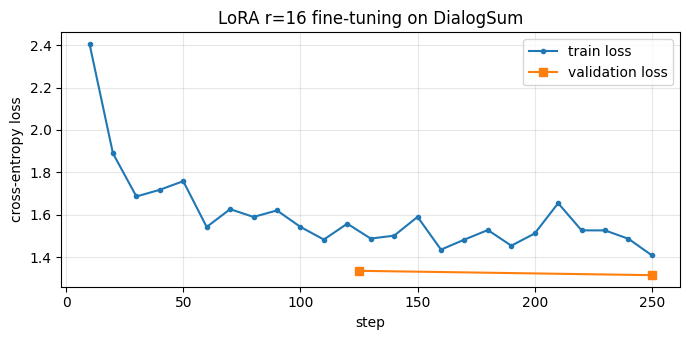

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(train_log16.step, train_log16.loss, marker="o", ms=3, label="train loss")
steps_per_epoch = train_log16.step.max() / train_log16.epoch.max()
ax.plot(eval_log16.epoch * steps_per_epoch, eval_log16.eval_loss, marker="s", label="validation loss")
ax.set_xlabel("step"); ax.set_ylabel("cross-entropy loss"); ax.set_title("LoRA r=16 fine-tuning on DialogSum")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/loss_curve_r16.png", dpi=120); plt.show()

In [12]:
ADAPTER_DIR16 = f"{OUT_DIR}/lora_adapter_r16"
lora16.save_pretrained(ADAPTER_DIR16)
tokenizer.save_pretrained(ADAPTER_DIR16)
for fn in sorted(os.listdir(ADAPTER_DIR16)):
    print(f"{fn:35s} {os.path.getsize(os.path.join(ADAPTER_DIR16, fn)) / 1e6:8.2f} MB")

README.md                               0.01 MB
adapter_config.json                     0.00 MB
adapter_model.safetensors               2.77 MB
tokenizer.json                          2.42 MB
tokenizer_config.json                   0.00 MB


/Users/rajesh_paruchuri/Desktop/GENAI/Homeworks/HW_5/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:313: UserWarning: Could not find a config file in google/flan-t5-small - will assume that the vocabulary was not modified.
  warnings.warn(


## 5. Post-Fine-Tuning Inference

Reload the saved adapter on top of a fresh copy of the base model (this also verifies the saved adapter works), then summarize the **same 2 test dialogues** with the same greedy decoding.

In [13]:
# free the training copy before loading the saved adapter (keeps memory within 16 GB)
del trainer16, lora16
import gc; gc.collect()
if DEVICE == "mps": torch.mps.empty_cache()

ft16 = PeftModel.from_pretrained(AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME), ADAPTER_DIR16).to(DEVICE)
ft16_outputs = summarize(ft16, eval_dialogues)

for i, out in enumerate(ft16_outputs):
    print(f"================ Test dialogue {EVAL_IDX[i]} ================")
    print("REFERENCE          :", eval_refs[i])
    print("FINE-TUNED (r=16)  :", out, "\n")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


================ Test dialogue 0 ================
REFERENCE          : Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.
FINE-TUNED (r=16)  : #Person1# asks #Person2# to take a dictation for Ms. Dawson. Ms. Dawson tells #Person1# that the use of instant messaging programs by employees during working hours is strictly prohibited. 

================ Test dialogue 1 ================
REFERENCE          : #Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.
FINE-TUNED (r=16)  : #Person1# tells #Person2# that #Person2#'s got stuck in traffic again. #Person2# thinks it's better if #Person1# started taking public transport system to work. #Person1# thinks biking to work would be better for the environment. 



## 6. Output Comparison: Before vs After Fine-Tuning

In [14]:
comparison = pd.DataFrame({
    "test_idx": EVAL_IDX,
    "Reference": eval_refs,
    "Before (zero-shot)": baseline_outputs,
    "After (LoRA r=16)": ft16_outputs,
})
display(comparison)

rouge_results["LoRA r=16"] = rouge_eval(ft16)
display(pd.DataFrame(rouge_results).T)

,test_idx,Reference,Before (zero-shot),After (LoRA r=16)
0,0,Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.,"Ms. Dawson, Attached is a draft memo to all employees.",#Person1# asks #Person2# to take a dictation for Ms. Dawson. Ms. Dawson tells #Person1# that the use of instant messaging programs by employees during working hours is strictly prohibited.
1,1,#Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.,Talk to a friend.,#Person1# tells #Person2# that #Person2#'s got stuck in traffic again. #Person2# thinks it's better if #Person1# started taking public transport system to work. #Person1# thinks biking to work would be better for the environment.


,rouge1,rouge2,rougeL,avg_words
Baseline (zero-shot),17.45,5.33,14.89,10.7
LoRA r=16,37.63,12.78,29.89,23.0


**What changed:**
- **Before**, flan-t5-small does not really summarize: it emits one short, often off-topic line — *"Ms. Dawson, Attached is a draft memo to all employees."* reads like the start of the memo itself, and *"Talk to a friend."* is unrelated to a dialogue about commuting (baseline average 10.7 words, ROUGE-1 17.45 on all 167 test dialogues).
- **After** LoRA (r=16), outputs follow the DialogSum style: 2–3 third-person sentences, ~23 words (references average 19.3), naming speakers with `#Person1#`/`#Person2#` tags and covering the main events (the Instant-Messaging ban; being stuck in traffic → taking public transport / biking). ROUGE-1 rises 17.45 → 37.63 and ROUGE-2 5.33 → 12.78, having trained only 0.89% of the parameters.
- The remaining errors are about **who did what**: in dialogue 0 it says *Ms. Dawson* tells #Person1# about the ban (it is #Person1# dictating to her), and in dialogue 1 it reverses who suggests public transport. The fine-tuned model learned the format and main content, but not reliable speaker attribution.

## 7. Experiment: LoRA rank r=4 vs r=16

Train a second adapter with **r = 4** (α = 8, same α/r = 2 scale) and *everything else identical* — same seed, data order, learning rate, epochs, target modules, and decoding — so the rank is the only variable.

In [15]:
del ft16
gc.collect()
if DEVICE == "mps": torch.mps.empty_cache()

lora4, cfg4 = build_lora_model(r=4, alpha=8)
total4, trainable4 = count_params(lora4)
print(f"r=4 : total {total4:,} | trainable {trainable4:,} ({100 * trainable4 / total4:.3f}%)")
print(f"r=16: total {total:,} | trainable {trainable:,} ({100 * trainable / total:.3f}%)")

trainer4, result4, logs4, mins4 = train_lora(lora4, "r4")
ADAPTER_DIR4 = f"{OUT_DIR}/lora_adapter_r4"
lora4.save_pretrained(ADAPTER_DIR4)
print(f"r=4 training time: {mins4:.1f} min | final (average) training loss: {result4.training_loss:.4f}")

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


r=4 : total 77,133,184 | trainable 172,032 (0.223%)
r=16: total 77,649,280 | trainable 688,128 (0.886%)


Epoch,Training Loss,Validation Loss
1,1.595193,1.352944
2,1.452161,1.337801


r=4 training time: 12.2 min | final (average) training loss: 1.6575


/Users/rajesh_paruchuri/Desktop/GENAI/Homeworks/HW_5/.venv/lib/python3.13/site-packages/peft/utils/save_and_load.py:313: UserWarning: Could not find a config file in google/flan-t5-small - will assume that the vocabulary was not modified.
  warnings.warn(


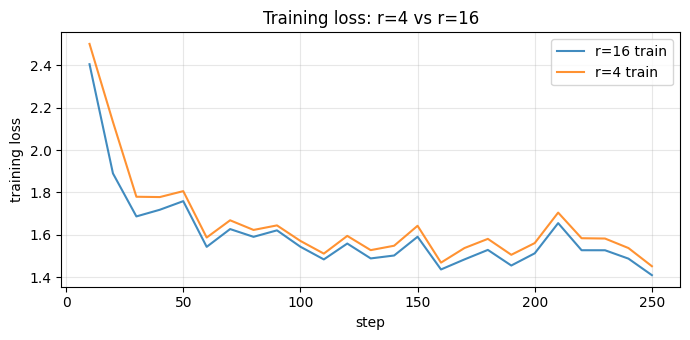

In [16]:
train_log4 = logs4.dropna(subset=["loss"])[["step", "epoch", "loss"]].reset_index(drop=True)
eval_log4 = logs4.dropna(subset=["eval_loss"])[["epoch", "eval_loss"]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(train_log16.step, train_log16.loss, label="r=16 train", alpha=0.85)
ax.plot(train_log4.step, train_log4.loss, label="r=4 train", alpha=0.85)
ax.set_xlabel("step"); ax.set_ylabel("training loss"); ax.set_title("Training loss: r=4 vs r=16")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{OUT_DIR}/loss_curve_r4_vs_r16.png", dpi=120); plt.show()

del trainer4
gc.collect()
if DEVICE == "mps": torch.mps.empty_cache()
ft4 = lora4.to(DEVICE)
ft4_outputs = summarize(ft4, eval_dialogues)
rouge_results["LoRA r=4"] = rouge_eval(ft4)

In [17]:
rank_table = pd.DataFrame([
    {"Rank r": 4, "alpha": 8, "Trainable params": trainable4, "% of total": round(100 * trainable4 / total4, 3),
     "Train time (min)": round(mins4, 1), "Avg train loss": round(result4.training_loss, 4),
     "Final logged train loss": round(train_log4.loss.iloc[-1], 4), "Final val loss": round(eval_log4.eval_loss.iloc[-1], 4),
     **{k: v for k, v in rouge_results["LoRA r=4"].items()}},
    {"Rank r": 16, "alpha": 32, "Trainable params": trainable, "% of total": round(100 * trainable / total, 3),
     "Train time (min)": round(mins16, 1), "Avg train loss": round(result16.training_loss, 4),
     "Final logged train loss": round(train_log16.loss.iloc[-1], 4), "Final val loss": round(eval_log16.eval_loss.iloc[-1], 4),
     **{k: v for k, v in rouge_results["LoRA r=16"].items()}},
])
display(rank_table)
print(f"All models, ROUGE on the same {N_ROUGE} unique test dialogues (3 refs each):")
display(pd.DataFrame(rouge_results).T)

,Rank r,alpha,Trainable params,% of total,Train time (min),Avg train loss,Final logged train loss,Final val loss,rouge1,rouge2,rougeL,avg_words
0,4,8,172032,0.223,12.2,1.6575,1.4522,1.3378,38.04,13.45,30.46,22.6
1,16,32,688128,0.886,18.3,1.6016,1.4099,1.3167,37.63,12.78,29.89,23.0


All models, ROUGE on the same 167 unique test dialogues (3 refs each):


,rouge1,rouge2,rougeL,avg_words
Baseline (zero-shot),17.45,5.33,14.89,10.7
LoRA r=16,37.63,12.78,29.89,23.0
LoRA r=4,38.04,13.45,30.46,22.6


In [18]:
side_by_side = pd.DataFrame({
    "test_idx": EVAL_IDX,
    "Reference": eval_refs,
    "Baseline": baseline_outputs,
    "LoRA r=4": ft4_outputs,
    "LoRA r=16": ft16_outputs,
})
display(side_by_side)

with open(f"{OUT_DIR}/all_outputs.json", "w") as f:
    json.dump({"samples": side_by_side.to_dict(orient="records"), "rouge_test_167_unique_3refs": rouge_results,
               "rank_table": rank_table.to_dict(orient="records")}, f, indent=2)
print(f"Saved -> {OUT_DIR}/all_outputs.json")

,test_idx,Reference,Baseline,LoRA r=4,LoRA r=16
0,0,Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.,"Ms. Dawson, Attached is a draft memo to all employees.",#Person1# asks #Person2# to take a dictation for Ms. Dawson. Ms. Dawson asks #Person1# to go out as an intra-office memorandum to all employees by this afternoon.,#Person1# asks #Person2# to take a dictation for Ms. Dawson. Ms. Dawson tells #Person1# that the use of instant messaging programs by employees during working hours is strictly prohibited.
1,1,#Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.,Talk to a friend.,#Person1# is stuck in traffic again. #Person2# thinks it would be better if #Person1# started taking public transport system to work. #Person1# thinks the public transport system would be better for the environment.,#Person1# tells #Person2# that #Person2#'s got stuck in traffic again. #Person2# thinks it's better if #Person1# started taking public transport system to work. #Person1# thinks biking to work would be better for the environment.


Saved -> outputs/all_outputs.json


**Rank experiment findings (r=4 vs r=16, everything else identical):**
- **Capacity/loss:** r=16 trains 4× more parameters (688,128 vs 172,032) and fits slightly better: validation loss 1.317 vs 1.338 and final logged train loss 1.410 vs 1.452.
- **Output quality:** that small loss advantage **does not show up in ROUGE**: r=4 is marginally *higher* (ROUGE-1 38.04 vs 37.63, ROUGE-2 13.45 vs 12.78, ROUGE-L 30.46 vs 29.89). The gaps are under 0.7 points on 167 dialogues, most likely within run-to-run noise. Both produce well-formed summaries of similar length (22.6 vs 23.0 words). On the two fixed dialogues, r=16 captured slightly more of the key content: it names the Instant-Messaging ban in dialogue 0, where r=4 only restates the memo logistics, and it correctly says #Person2# got stuck in traffic in dialogue 1, where r=4 attributes it to #Person1#. Both still swap some speaker roles.
- **Conclusion:** for this small model and 1,000-dialogue subset, **r=4 is sufficient**; going to r=16 buys a little lower loss but no measurable ROUGE gain, at 4× the adapter size (0.70 MB vs 2.77 MB). (Wall-clock time, 12.2 vs 18.3 min, differed because of memory pressure on the machine during the r=16 run, not because of the rank — LoRA's rank adds negligible compute here.)